<a href="https://colab.research.google.com/github/juanpajaro/aprendizaje_profundo_salud_puj_2026/blob/main/Tf_idf_redes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#preprocesamiento
import pandas as pd
import numpy as np
import re

#ingeniería de caracteristicas
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

#visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

#algoritmos
import keras
from keras import layers

In [2]:
datos = pd.read_csv('/content/datos_apnea.csv')
datos.head()

,EnfermedadActual,Apnea
0,ACUDE PACIENTE A CONSULTA CON CUADRO DE DELARA...,No
1,CUADRO DE CEFALEA GLOBAL INTENSIDAD MODERADA. ...,No
2,PACIENTE CON ANTECEDENTE DE HIPOTIRODISMO DE L...,NaN
3,PACIENTE DE 44 AÑOS DE EDAD QUIEN ASISTE A CON...,No
4,PACIENTE CON HIPOTIRODISMO DX EN EL EMBARAZO H...,No


In [3]:
#convert NaN in datos["Apnea"] to 1 and "No" to cero
datos["Apnea"] = datos["Apnea"].fillna(1)
datos["Apnea"] = datos["Apnea"].replace("No", 0)
datos["Apnea"].value_counts()

/tmp/ipykernel_29213/3173026645.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos["Apnea"] = datos["Apnea"].replace("No", 0)


,count
Apnea,
0,57733
1,42267


In [4]:
text_raw = datos["EnfermedadActual"].to_numpy()
print(type(text_raw))
y_raw = datos["Apnea"].to_numpy()
print(type(y_raw))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [5]:
def encontrar_palabras(oracion):
  #reemplaza signos de puntuacion por puntos
  oracion_limpia = re.sub(r'[,!?;-]', '.', oracion)
  #convertir la oración en minuscula
  oracion_minuscula = oracion_limpia.lower()
  #eliminar comillas dobles y simples
  oracion_sin_comilla = re.sub(r'["\']', '', oracion_minuscula)
  #se eliminan espacios
  l_oracion = oracion_sin_comilla.split()
  oracion_final = [palabra.strip() for palabra in l_oracion]
  return " ".join(oracion_final)

In [6]:
for i in range(len(text_raw)):
  text_raw[i] = encontrar_palabras(text_raw[i])

print(text_raw[1])

cuadro de cefalea global intensidad moderada. le genera mareo. si tinitus oido derecho. no fotopsias. si escotomas. las despierta a veces. refire asociacion con dolor ocipital. no sincope no precordialgia no disnea. ha tomado acetaminofe. no le sirve. hipotiroidea y dislipidemia


In [7]:
def split_data(text_data, labels, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Divide los datos de texto y etiquetas en conjuntos de entrenamiento, validación y prueba.

    Args:
        text_data (np.ndarray): Array NumPy de datos de texto.
        labels (np.ndarray): Array NumPy de etiquetas correspondientes.
        train_ratio (float): Proporción de datos para el conjunto de entrenamiento.
        val_ratio (float): Proporción de datos para el conjunto de validación.
        test_ratio (float): Proporción de datos para el conjunto de prueba.
        random_state (int, optional): Semilla para la reproducibilidad del split. Defaults to 42.

    Returns:
        tuple: Una tupla que contiene (X_train, X_val, X_test, y_train, y_val, y_test).
    """
    if not (train_ratio + val_ratio + test_ratio == 1.0):
        raise ValueError("Las proporciones de entrenamiento, validación y prueba deben sumar 1.0")

    # Primero, dividir en entrenamiento y un conjunto temporal (validación + prueba)
    X_train, X_temp, y_train, y_temp = train_test_split(
        text_data, labels, test_size=(val_ratio + test_ratio), random_state=random_state, stratify=labels
    )

    # Luego, dividir el conjunto temporal en validación y prueba
    # La proporción para el test_size debe ser relativa al tamaño de X_temp
    test_size_relative = test_ratio / (val_ratio + test_ratio)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size_relative, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(text_raw, y_raw)

In [9]:
print(f"Tamaño de los datos de entrenamiento: {len(X_train)}")
print(f"Tamaño de los datos de validación: {len(X_val)}")
print(f"Tamaño de los datos de prueba: {len(X_test)}")

Tamaño de los datos de entrenamiento: 70000
Tamaño de los datos de validación: 15000
Tamaño de los datos de prueba: 15000


In [10]:
def apply_tfidf(text_data, max_features=None, min_df=1, max_df=1.0, ngram_range=(1, 1), stop_words=None):
  """
  Aplica TF-IDF (Term Frequency-Inverse Document Frequency) a los datos de texto.

  Args:
    text_data (list or numpy.ndarray): La lista o array de documentos de texto.
    max_features (int, optional): El número máximo de características (tokens) a considerar.
                                  Si no es None, el vectorizador construirá un vocabulario
                                  que solo incluye las palabras más frecuentes hasta este número.
                                  Defaults to None.
    min_df (float or int, optional): Cuando se construye el vocabulario, ignora los términos
                                    que tienen una frecuencia de documento inferior al umbral dado.
                                    Si es un float, representa una proporción del número total de documentos.
                                    Si es un int, representa el recuento absoluto de documentos.
                                    Defaults to 1.
    max_df (float or int, optional): Cuando se construye el vocabulario, ignora los términos
                                    que tienen una frecuencia de documento superior al umbral dado.
                                    Si es un float, representa una proporción del número total de documentos.
                                    Si es un int, representa el recuento absoluto de documentos.
                                    Defaults to 1.0.
    ngram_range (tuple, optional): El rango (min_n, max_n) para diferentes valores de n de n-gramas
                                   a extraer. Por ejemplo, (1, 1) significa solo unigramas, (1, 2) significa
                                   unigramas y bigramas. Defaults to (1, 1).
    stop_words (str or list, optional): Una lista de palabras a ignorar, o el string 'english'
                                        para usar una lista incorporada en scikit-learn.
                                        Defaults to None.

  Returns:
    tuple: Una tupla que contiene:
           - tfidf_matrix (scipy.sparse.csr_matrix): La matriz TF-IDF de los datos de texto.
           - vectorizer (TfidfVectorizer): El objeto TfidfVectorizer ajustado.
  """
  vectorizer = TfidfVectorizer(
      max_features=max_features,
      min_df=min_df,
      max_df=max_df,
      ngram_range=ngram_range,
      stop_words=stop_words
  )
  tfidf_matrix = vectorizer.fit_transform(text_data)
  return tfidf_matrix, vectorizer

In [11]:
X_train_tfidf, vectorizer = apply_tfidf(X_train, max_features=5000, stop_words='english', ngram_range=(1,2))
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

In [12]:
print("Forma de la matriz TF-IDF:", X_train_tfidf.shape)
print("Primeras 50 características (palabras):")
print(vectorizer.get_feature_names_out()[2500:2550])

Forma de la matriz TF-IDF: (70000, 5000)
Primeras 50 características (palabras):
['hta' 'hta controlada' 'hta cronica' 'hta desde' 'hta diabetes'
 'hta dislipidemia' 'hta dm' 'hta en' 'hta epoc' 'hta hace'
 'hta hiperlipidemia' 'hta hipotiroidismo' 'hta obesidad' 'hta quien'
 'hta refiere' 'hta sin' 'htc' 'hto' 'humeda' 'ia' 'iam' 'ibuprofeno'
 'ido' 'idx' 'iega' 'igual' 'ii' 'iii' 'iliaca' 'im' 'imagen' 'imagenes'
 'implante' 'importancia' 'inasistente' 'incapacidad' 'incontinencia'
 'incontinencia urinaria' 'incrementa' 'incremento' 'independiente'
 'indica' 'indica que' 'indicacion' 'indicada' 'indicado' 'indicados'
 'indican' 'indicaron' 'indico']


In [14]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_train_tfidf.toarray())

In [18]:
df = pd.DataFrame(coords, columns=['coord1', 'coord2'])
df['Categoria'] = y_train
df['Documento'] = X_train
df.head()

,coord1,coord2,Categoria,Documento
0,-0.073584,0.023433,0,paciente femenino de 36 años de edad. con obes...
1,-0.011447,0.021805,1,paciente de 65 años. cc de 1 mes consistente e...
2,-0.029900,0.015660,0,pcte 37 años con disuria de ador polaquiuria. ...
3,-0.001402,0.052766,0,femenino de 69 años. con historia de alcoholis...
4,-0.013944,0.067548,1,paciente de 66 años de edad quien consulta por...


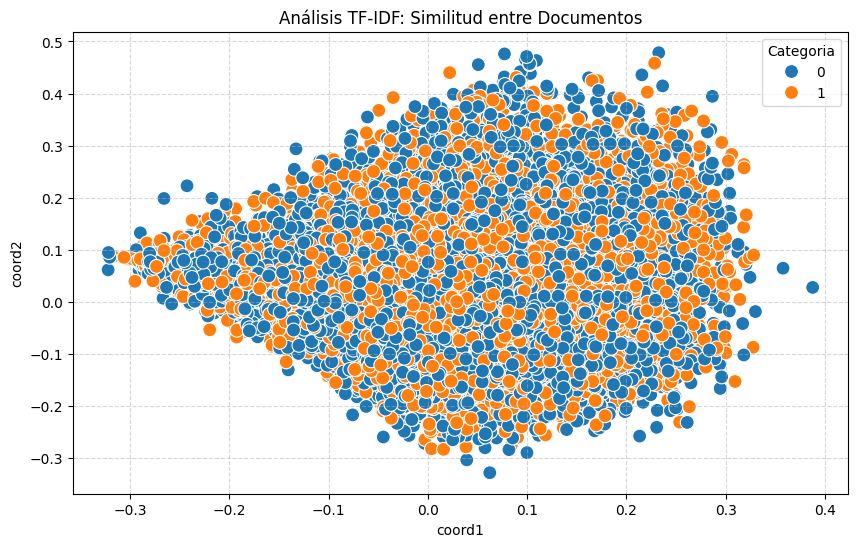

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='coord1', y='coord2', hue='Categoria', s=100)
plt.title("Análisis TF-IDF: Similitud entre Documentos")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [21]:
feature_names = vectorizer.get_feature_names_out()
df_w = pd.DataFrame(X_train_tfidf.toarray(), columns=feature_names)


In [25]:
print(df_w.iloc[0].sort_values(ascending=False).head(50))

fluoxetina           0.259289
por este             0.256153
tratamiento          0.255932
obesidad en          0.254763
omeprazol            0.233838
36 años              0.221789
bajo                 0.220051
paciente femenino    0.218260
al tratamiento       0.209565
adherencia al        0.207659
buena adherencia     0.203893
seguimiento por      0.202546
femenino             0.198771
36                   0.198310
en seguimiento       0.194745
este                 0.194607
metformina           0.188726
buena                0.183589
seguimiento          0.168912
adherencia           0.166885
obesidad             0.154256
programa             0.146338
al                   0.113773
años edad            0.089595
edad                 0.087947
años                 0.062633
por                  0.061642
paciente             0.052138
en                   0.049859
normal glicemia      0.000000
normal en            0.000000
normal creatinina    0.000000
nota                 0.000000
normal    

In [27]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [28]:
history = model.fit(
    X_train_tfidf,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(X_val_tfidf, y_val),
)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5771 - loss: 0.6792 - val_accuracy: 0.5935 - val_loss: 0.6704
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.6160 - loss: 0.6479 - val_accuracy: 0.6015 - val_loss: 0.6521
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6460 - loss: 0.6192 - val_accuracy: 0.5925 - val_loss: 0.6512
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.6585 - loss: 0.6056 - val_accuracy: 0.5973 - val_loss: 0.6517
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6693 - loss: 0.5950 - val_accuracy: 0.6010 - val_loss: 0.6539
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6794 - loss: 0.5840 - val_accuracy: 0.5993 - val_loss: 0.6573
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6954 - loss: 0.5714 - val_accuracy: 0.5911 - val_loss: 0.6676
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7102 - loss: 0.5550 - val_acc

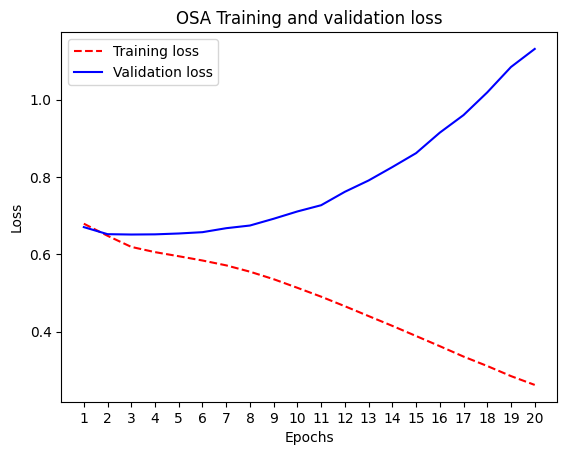

In [29]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("OSA Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()